### 라이브러리 설치 및 Import

In [2]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 시각화

In [3]:
df = pd.read_csv('../../Data/merged_df.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306137 non-null  str    
 1   event             306137 non-null  str    
 2   time              306137 non-null  int64  
 3   offer_id          167184 non-null  str    
 4   amount            138953 non-null  float64
 5   bonus_reward      33182 non-null   float64
 6   time_days         306137 non-null  int64  
 7   gender            306137 non-null  str    
 8   age               272388 non-null  float64
 9   customer_id       306137 non-null  str    
 10  became_member_on  306137 non-null  str    
 11  income            272388 non-null  float64
 12  income_missing    306137 non-null  int64  
 13  age_missing       306137 non-null  int64  
 14  reward            167184 non-null  float64
 15  difficulty        167184 non-null  float64
 16  duration          167184 non-nu

### 전체(핵심 지표 소개)

#### 총 오퍼 퍼널 분석

In [5]:
# 총 발송 수
cnt_received = df['customer_id'][df['event']=='received'].count()
print("총 발송 수:")
print(cnt_received)

총 발송 수:
76277


In [6]:
# 총 열람 수
cnt_viewed = df['customer_id'][df['event']=='viewed'].count()
print("총 열람 수:")
print(cnt_viewed)

총 열람 수:
57725


In [7]:
# 총 완료 수
cnt_completed = df['customer_id'][df['event']=='completed'].count()
print("총 완료 수:")
print(cnt_completed)

총 완료 수:
33182


In [8]:
# 발송 → 열람 전환율
ratio_received_viewed = cnt_viewed / cnt_received * 100
print("발송 → 열람 전환율:")
print(f'{ratio_received_viewed:.2f}%')

발송 → 열람 전환율:
75.68%


In [9]:
# 열람 → 완료 전환율
ratio_viewed_completed = cnt_completed / cnt_viewed * 100
print("열람 → 완료 전환율:")
print(f'{ratio_viewed_completed:.2f}%')

열람 → 완료 전환율:
57.48%


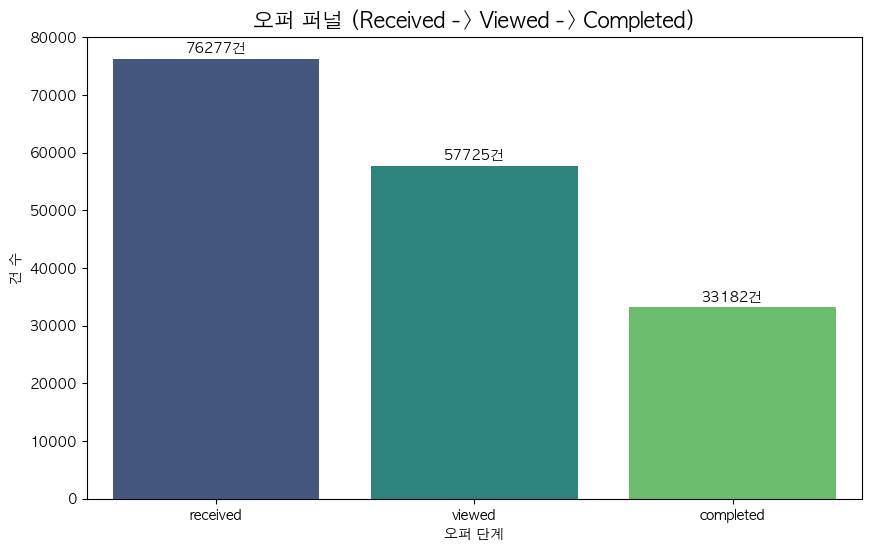

In [10]:
offer_events = ['received', 'viewed', 'completed']
funnel_df = df[df['event'].isin(offer_events)]

overall_funnel = funnel_df['event'].value_counts().reindex(offer_events)

# 시각화 1: 전체 퍼널 현황
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=overall_funnel.index, y=overall_funnel.values, palette='viridis')

plt.title('오퍼 퍼널 (Received -> Viewed -> Completed)', fontsize=15)
plt.ylabel('건 수')
plt.xlabel('오퍼 단계')

# 막대 위에 값 표시
for i, v in enumerate(overall_funnel):
    ax.text(i, v + 1000, f"{v:.0f}건", ha='center')

plt.show()

#### 전체 매출 관련

In [11]:
# 총 매출
total_revenue = df['amount'].sum()
print("총 매출:")
print(f'${total_revenue:,.0f}')

총 매출:
$1,775,452


In [12]:
# 총 거래 건수
total_cnt = df['amount'].count()
print("총 거래 건수:")
print(f'{total_cnt:,}')

총 거래 건수:
138,953


In [13]:
df['amount'].describe()

count    138953.000000
mean         12.777356
std          30.250529
min           0.050000
25%           2.780000
50%           8.890000
75%          18.070000
max        1062.280000
Name: amount, dtype: float64

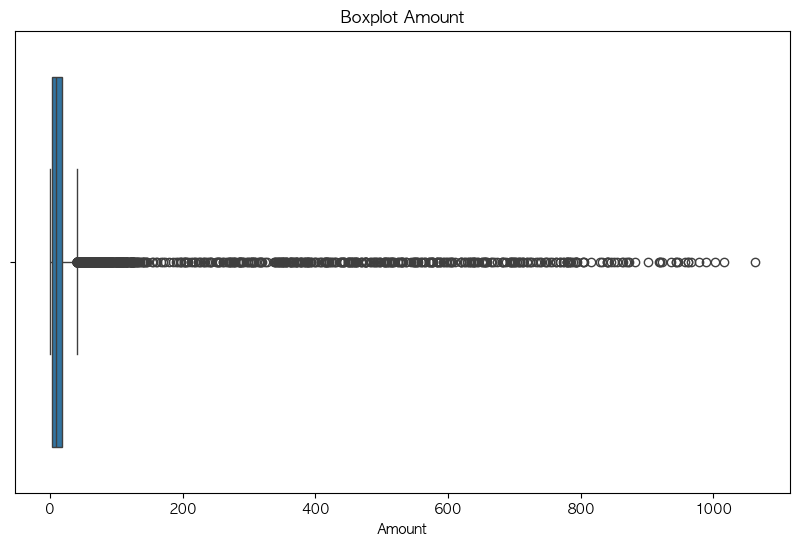

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['amount'].dropna())
plt.title('Boxplot Amount')
plt.xlabel('Amount')
plt.show()

#### 객단가

In [15]:
# 객단가(AOV - Average order value, 거래별 객단가) = 총 매출 / 총 거래 건수
aov = total_revenue / total_cnt
print("객단가(AOV):")
print(f'${aov:,.2f}')

객단가(AOV):
$12.78


In [16]:
# 총 고객별 객단가(ARPU - Average Revenue Per User) = 총 매출 / 총 고객 수
total_cnt_customer = df['customer_id'].count()

arpu = total_revenue / total_cnt_customer
print("객단가(ARPU):")
print(f'${arpu:,.2f}')

객단가(ARPU):
$5.80


In [17]:
# 고객별 객단가 = 고객별 총 매출 / 고객별 거래 수
transactions = df[df['event'] == 'transaction'] 

customer_stats = transactions.groupby('person')['amount'].agg(['sum', 'count', 'mean']).reset_index() 

print(customer_stats.head())

                             person     sum  count       mean
0  0009655768c64bdeb2e877511632db8f  127.60      8  15.950000
1  00116118485d4dfda04fdbaba9a87b5c    4.09      3   1.363333
2  0011e0d4e6b944f998e987f904e8c1e5   79.46      5  15.892000
3  0020c2b971eb4e9188eac86d93036a77  196.86      8  24.607500
4  0020ccbbb6d84e358d3414a3ff76cffd  154.05     12  12.837500


#### 채널별 offer 고객 수(중복 O): 1개 offer에 제공되는 채널이 여러 개이므로

In [18]:
# 채널별 고객 수
cnt_web_customer = df['customer_id'][df['web']==1].count()
cnt_email_customer = df['customer_id'][df['email']==1].count()
cnt_mobile_customer = df['customer_id'][df['mobile']==1].count()
cnt_social_customer = df['customer_id'][df['social']==1].count()

print("채널별 고객 수:")
print(f'web: {cnt_web_customer:,}명')
print(f'email: {cnt_email_customer:,}명')
print(f'mobile: {cnt_mobile_customer:,}명')
print(f'social: {cnt_social_customer:,}명')

채널별 고객 수:
web: 134,870명
email: 167,184명
mobile: 153,513명
social: 109,887명


> 발송이 되어야만 열람/완료가 진행되는 구조라면,  
> 발송 기록이 있는 고객만 count를 해서 채널별 데이터 중복을 막을 수 있음

#### 전체 기록 고객 수

In [19]:
# 전체 고객 수
cnt_customer = df['customer_id'].count()

print("전체 고객 수:")
print(f'{cnt_customer:,}명')

전체 고객 수:
306,137명


#### 고유 고객 수

In [20]:
# 고유 고객 수
cnt_customer_unique = df['customer_id'].nunique()

print("고유 고객 수:")
print(f'{cnt_customer_unique:,}명')

고유 고객 수:
17,000명


> 17,000명에 대한 1개월 치 offer 정보를 줬을지도?

In [21]:
received_df = df[df['event'] == 'received']

receive_counts = received_df.groupby(['customer_id', 'offer_id']).size().reset_index(name='receive_count')

multiple_receives = receive_counts[receive_counts['receive_count'] > 1]

print(f"2번 이상: {len(multiple_receives)}건")
print(multiple_receives.head(10))

2번 이상: 11718건
                         customer_id                          offer_id  \
5   00116118485d4dfda04fdbaba9a87b5c  f19421c1d4aa40978ebb69ca19b0e20d   
14  0020c2b971eb4e9188eac86d93036a77  fafdcd668e3743c1bb461111dcafc2a4   
22  003d66b6608740288d6cc97a6903f4f0  fafdcd668e3743c1bb461111dcafc2a4   
24  00426fe3ffde4c6b9cb9ad6d077a13ea  2906b810c7d4411798c6938adc9daaa5   
31  004c5799adbf42868b9cff0396190900  f19421c1d4aa40978ebb69ca19b0e20d   
32  004c5799adbf42868b9cff0396190900  fafdcd668e3743c1bb461111dcafc2a4   
35  005500a7188546ff8a767329a2f7c76a  ae264e3637204a6fb9bb56bc8210ddfd   
46  0069a50874d846438e58acff5e594725  2906b810c7d4411798c6938adc9daaa5   
48  00715b6e55c3431cb56ff7307eb19675  0b1e1539f2cc45b7b9fa7c272da2e1d7   
53  0082fd87c18f45f2be70dbcbb0fb8aad  3f207df678b143eea3cee63160fa8bed   

    receive_count  
5               2  
14              2  
22              2  
24              2  
31              2  
32              2  
35              3  
46         